In [156]:
from copy import copy
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib

from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala import plotting as pl
from alter_morph.lattice_utilities import add_contacts
from kwant import kpm

from koala.lattice import Lattice
from koala.graph_color import color_lattice
from tqdm import tqdm

from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_m_values,
    find_spin_per_state,
    fermi_probability,
    spectral_function,
)

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

import kwant
from alter_morph.kwant_version import Amorphous

from time import time

aps_figwidth = 6.6
aps_halfwidth = 3.375

In [157]:
from alter_morph.hamiltonians import _hopping_matrix


def kwant_altermagnetic_hamiltonian(
    lattice: Lattice, t1: float, t2: float, J: float, m_values: np.ndarray
):
    n_orbs = 4
    syst = kwant.Builder()
    k_lattice = Amorphous(n_orbs, lattice)

    for n in range(lattice.n_vertices):
        vertex_neighbours = lattice.vertices.adjacent_vertices[n]
        neighbour_magnetisations = m_values[vertex_neighbours]
        total_magnetisation = np.sum(neighbour_magnetisations)
        syst[k_lattice(n)] = J * total_magnetisation * np.diag(np.array([-1, 1, 1, -1]))

    for n_edge in range(lattice.n_edges):
        vector = lattice.edges.vectors[n_edge]
        e0, e1 = lattice.edges.indices[n_edge]
        theta = np.arctan2(vector[0], vector[1])
        h0_term = np.kron(np.eye(2), _hopping_matrix(t1, t2, theta))

        syst[k_lattice(e0), k_lattice(e1)] = h0_term
        syst[k_lattice(e1), k_lattice(e0)] = h0_term.T.conj()

    return syst


# def lattice_ham_to_kwant(lattice, hamiltonian):
#     n_orbs = hamiltonian.shape[0] // lattice.n_vertices

#     syst = kwant.Builder()
#     lat_kwant = Amorphous(n_orbs, lattice)

#     on_site_terms = [
#         hamiltonian[i * n_orbs : (i + 1) * n_orbs, i * n_orbs : (i + 1) * n_orbs]
#         for i in range(lattice.n_vertices)
#     ]

#     for i in range(lattice.n_vertices):
#         # print("on site", np.array(on_site_terms[i]))
#         syst[lat_kwant(i)] = on_site_terms[i]

#     for i in range(lattice.n_vertices):
#         for j in range(lattice.n_vertices):
#             if i != j:
#                 element = hamiltonian[
#                     i * n_orbs : (i + 1) * n_orbs, j * n_orbs : (j + 1) * n_orbs
#                 ]
#                 if la.norm(element) > 1e-8:
#                     syst[lat_kwant(i), lat_kwant(j)] = element

#     return syst

l0 done, time:  0.02
l1 done, time:  0.57
l2 done, time:  1.23
Lattice(400 vertices, 800 edges) Lattice(400 vertices, 600 edges) Lattice(399 vertices, 798 edges)


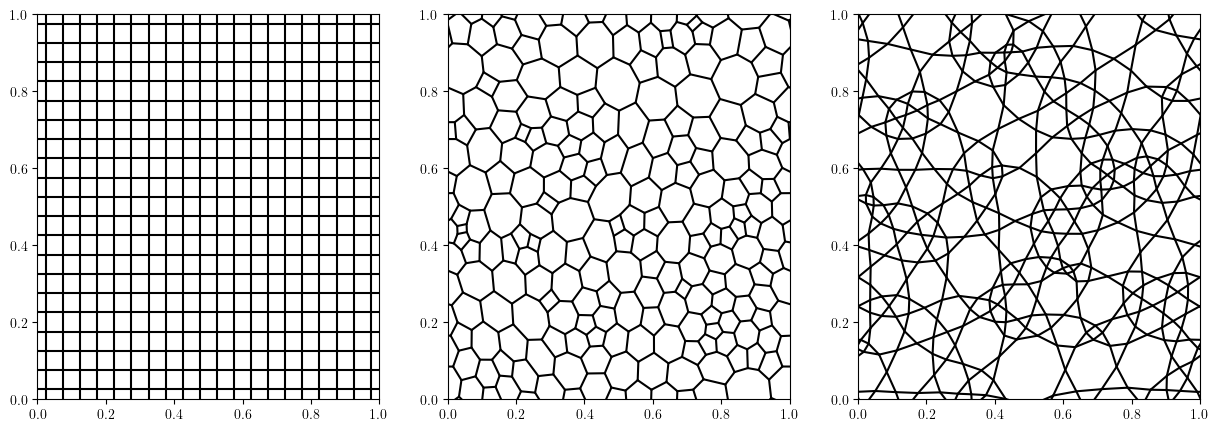

In [158]:
# generate the lattice
n_vertices = 20**2
points = uniform(n_vertices)
t0 = time()

rows = np.round(np.sqrt(n_vertices)).astype(int)
lattice0 = eg.square_lattice(rows, rows)
# lattice0, edges0 = add_contacts(lattice0, cross_edges=True,return_added_indices=True)
print(f"l0 done, time: {time() - t0: .2f}")

vor_lat = generate_lattice(uniform(n_vertices // 2))
dimerisation = gu.dimerise(vor_lat)
lattice1 = gu.lloyd_relaxation(vor_lat)
# lattice1, edges1 = add_contacts(lattice1, cross_edges=True,return_added_indices=True)
print(f"l1 done, time: {time() - t0: .2f}")

l2 = generate_lattice(uniform(n_vertices // 3))
l2 = gu.lloyd_relaxation(l2)
exp_lat = gu.vertices_to_polygon(l2)
dimer_exp = np.zeros(exp_lat.n_edges)
dimer_exp[: l2.n_edges] = 1
lattice2 = gu.dimer_collapse(exp_lat, dimer_exp)
# lattice2, edges2 = add_contacts(lattice2, cross_edges=True,return_added_indices=True)
print(f"l2 done, time: {time() - t0: .2f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
pl.plot_edges(lattice0, ax=ax[0])
pl.plot_edges(lattice1, ax=ax[1])


pl.plot_edges(lattice2, ax=ax[2])

print(lattice0, lattice1, lattice2)

In [ ]:
lat = lattice1
# lat, edges = add_contacts(
#     lat, cross_edges=True, return_added_indices=True, make_uniform=False
# )

t1 = 1
t2 = 0.3
J = 0.4
filling = 0.1

# left_sites, right_sites = edges

initial_m = np.zeros(lat.n_vertices) + 1.2

k_system = kwant_altermagnetic_hamiltonian(lat, t1, t2, J, initial_m)
k_system = k_system.finalized()


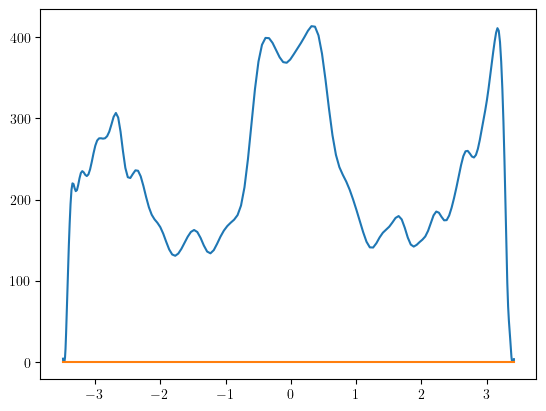

In [242]:
spectrum = kwant.kpm.SpectralDensity(k_system)
energies, densities = spectrum()

plt.plot(energies, densities.real)
plt.plot(energies, densities.imag)

In [ ]:
from scipy import sparse as sp


number_density = kwant.operator.Density(k_system, sum=False)
magnetisation = kwant.operator.Density(
    k_system, sum=False, onsite=np.diag([1, -1, -1, 1])
)
local_dos = kwant.kpm.SpectralDensity(k_system, operator=number_density)
local_mag = kwant.kpm.SpectralDensity(k_system, operator=magnetisation, num_vectors=50)


def distr(energy):
    return energy < 0


print(local_dos.integrate(distr))
print(local_mag.integrate(distr))


[2.02158187+2.18725934e-01j 2.02142872+7.57374858e-02j
 2.02405611+3.54782317e-01j 2.21596404-1.68690683e-01j
 1.89098501+1.01966608e-01j 1.70403813-1.19125516e-01j
 1.90919691-1.45342521e-01j 1.87138659-4.98069019e-02j
 2.08771971+7.21863902e-02j 1.88982125-8.70568713e-02j
 2.00614463-1.00003894e-01j 2.17111918-7.13775610e-02j
 1.9903501 -2.59338399e-01j 2.22037632+8.02812861e-02j
 2.12490342-1.39780854e-01j 1.72789998+9.27145570e-02j
 2.01584123+1.05649358e-01j 2.01902901+8.12807189e-02j
 2.30923332+2.34093028e-02j 2.05772715-2.43484009e-01j
 2.03212698-2.58870661e-01j 2.14920509-1.24706570e-01j
 2.02296908+4.44418264e-02j 2.09318861+1.58005749e-01j
 2.15303687-2.10035598e-01j 1.85324853+2.28042522e-01j
 1.88215032+6.11558653e-02j 1.9707818 -2.39955103e-01j
 1.71214156-7.75316556e-02j 2.07191296+7.34730797e-02j
 2.08485647-5.13770504e-02j 1.91210281-1.61087678e-01j
 1.98045621-6.76388799e-02j 2.08352735+4.99717009e-02j
 1.8445343 -1.19198446e-02j 1.85050787+2.33828824e-03j
 1.8346485

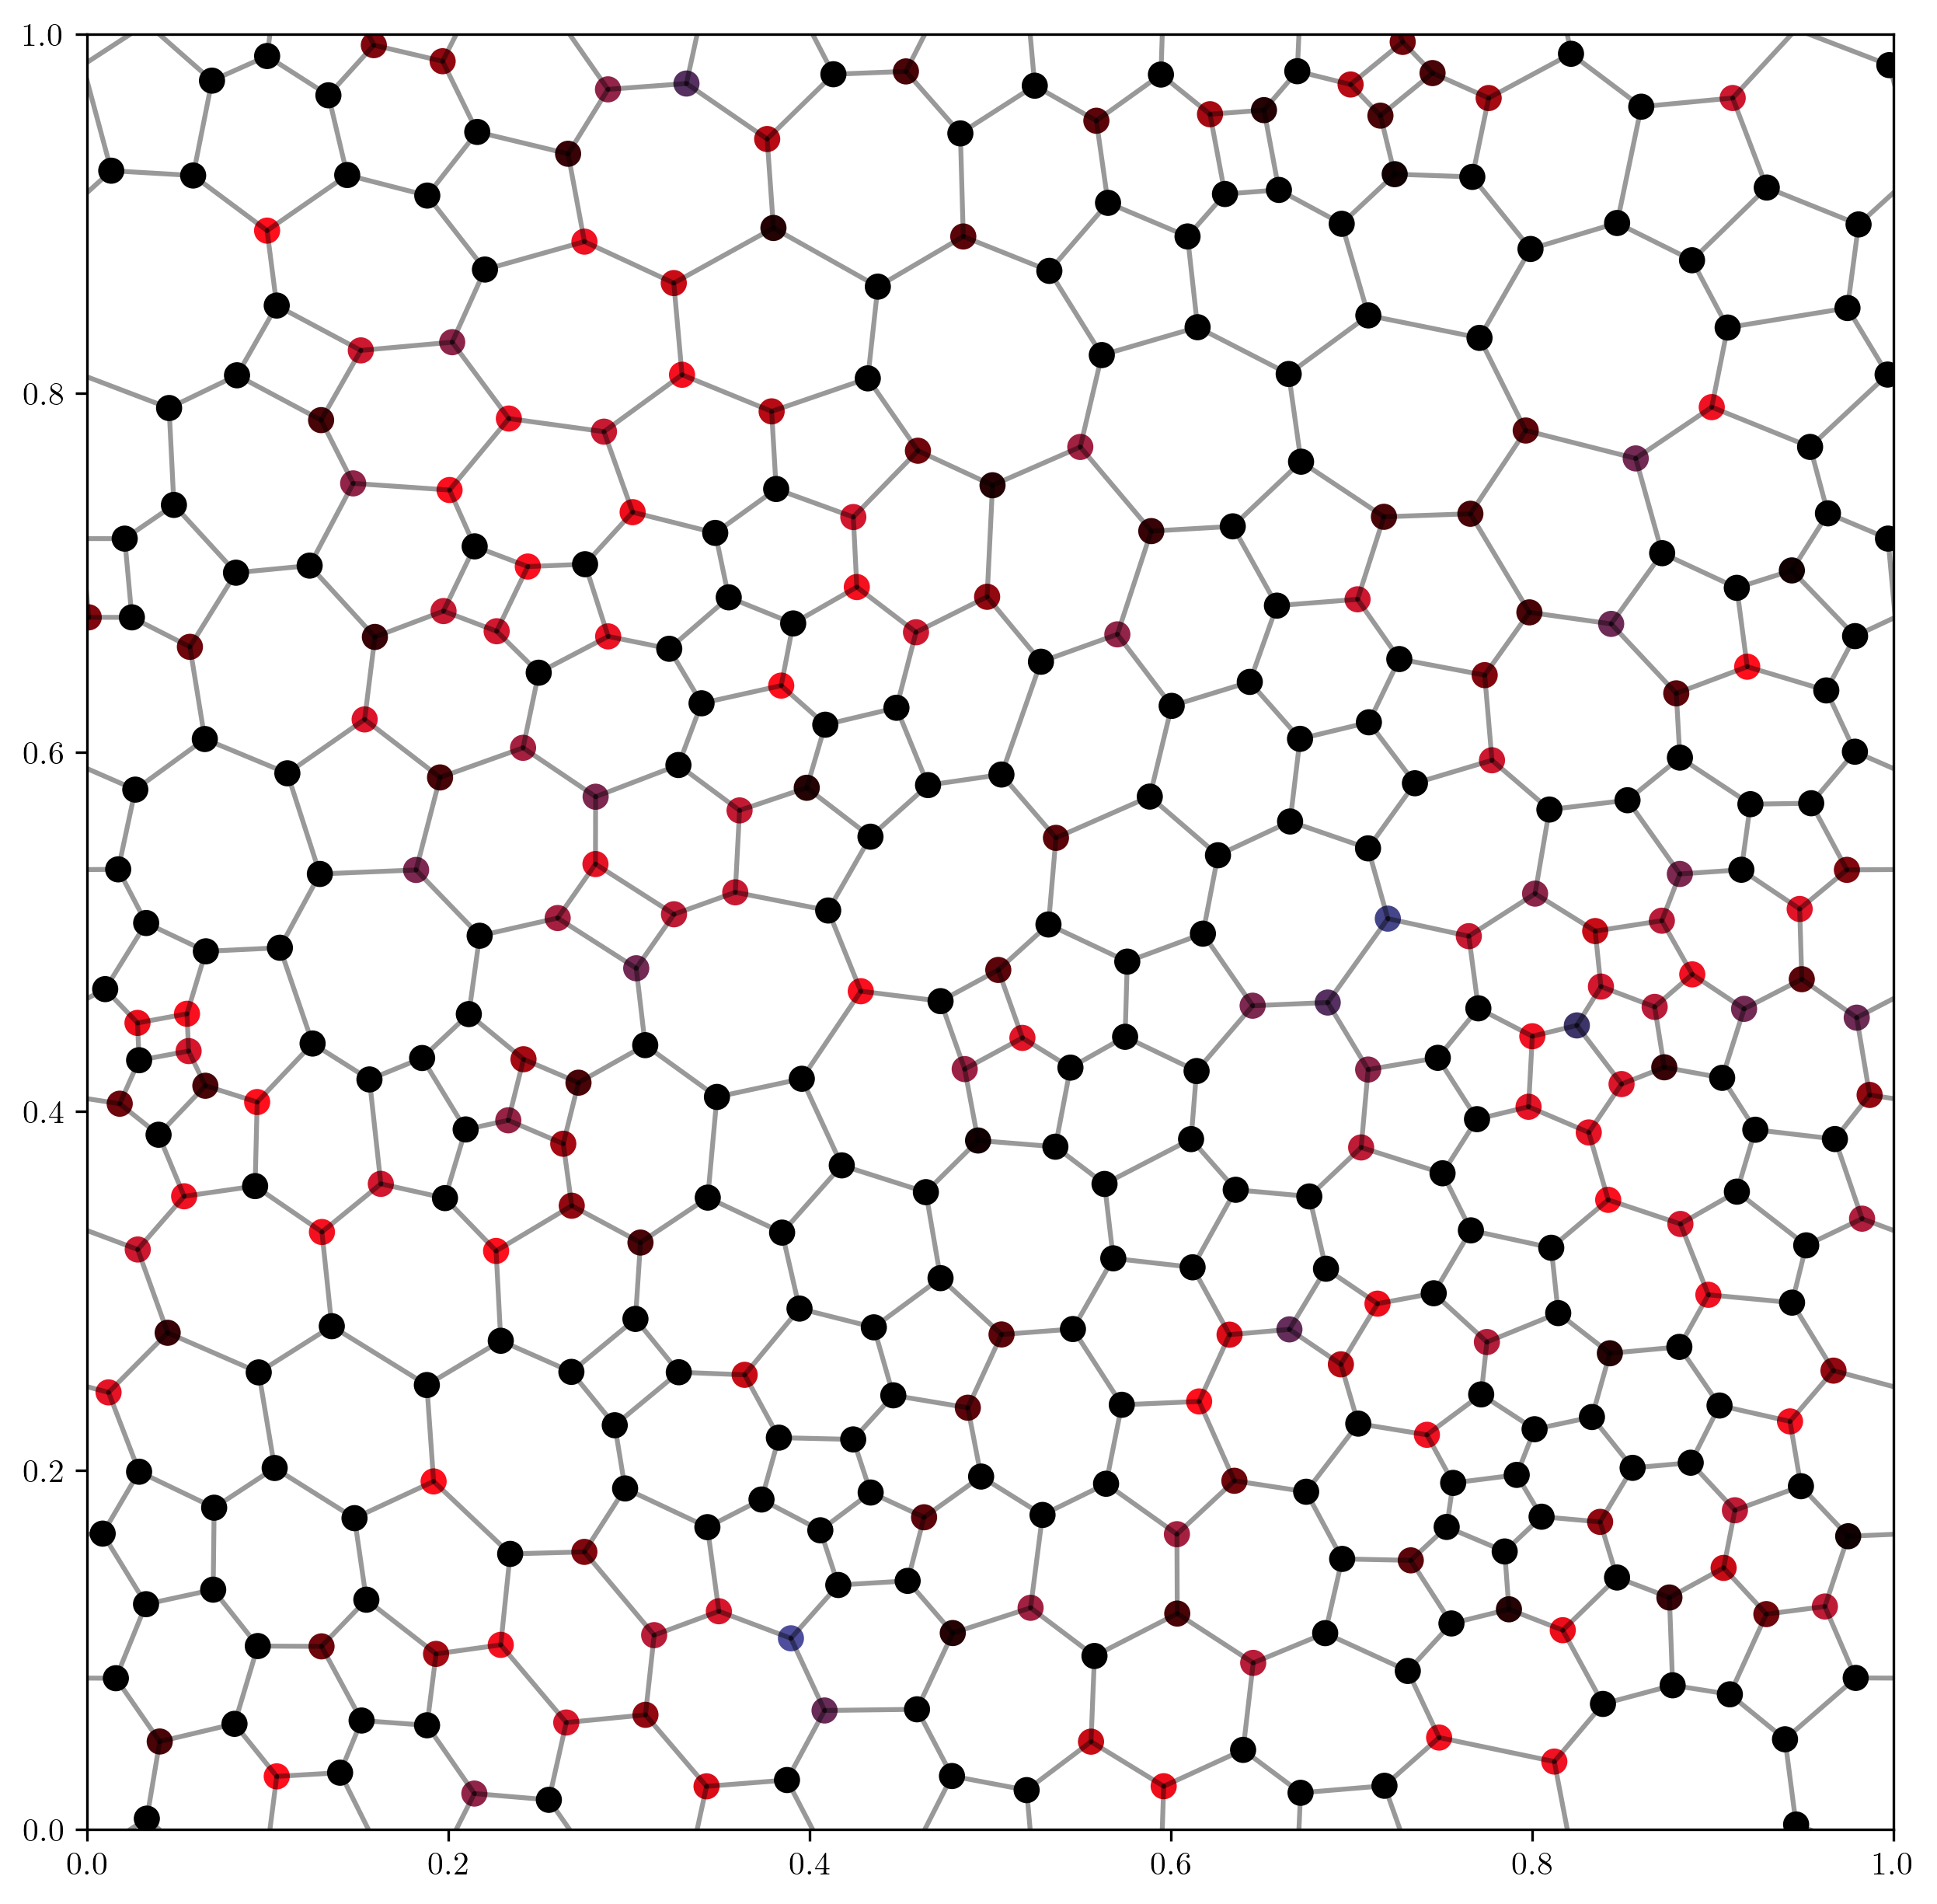

In [ ]:
lat.vertices.positions


dos_at_e = local_dos.integrate(distr)

vertices = lat.vertices.positions
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=300)

pl.plot_edges(lat, ax=ax, alpha=0.4)

im = ax.scatter(
    vertices[:, 0],
    vertices[:, 1],
    c=dos_at_e.real,
    cmap="gist_stern_r",
    s=50,
    vmin=0,
    vmax=2,
)
# fig.colorbar(im, ax=ax)
# plt.show()


In [165]:
dos_at_e

array([2.28181666-5.72226987e-02j, 1.89887703-3.17561222e-01j,
       2.11425529-9.47031431e-02j, 2.07779918+1.21349837e-01j,
       1.96922757+2.45278723e-01j, 1.86520248-1.58716101e-02j,
       1.62903304-3.37049002e-01j, 1.94135166+4.02494672e-01j,
       2.05544887+1.20347520e-01j, 2.14782313-9.92709454e-02j,
       1.88556754+1.60767253e-01j, 1.87394665-6.80424291e-02j,
       1.71894729-5.76321215e-02j, 2.29957143-9.54353751e-02j,
       1.78681189-2.84129213e-01j, 1.93694334+2.83913139e-01j,
       1.78322402+3.31620506e-01j, 1.86696362+4.98425396e-02j,
       2.06054462-9.32830130e-02j, 2.17481219-2.35036842e-01j,
       2.42772411-1.53808268e-02j, 1.86263318-3.27280560e-02j,
       1.99792777+1.21446177e-01j, 2.03975432+7.89736643e-02j,
       2.13786084+2.07884021e-01j, 2.12222117-1.57896226e-01j,
       1.84187091+3.00392993e-02j, 1.96007055-1.02319078e-01j,
       2.01315592-2.19797961e-04j, 1.89752737+1.17000075e-01j,
       2.23577523-1.77898758e-01j, 1.84748641+4.1750066

In [166]:
from scipy import sparse

num_moments = 100
num_vectors = 10
observable = np.diag

m_vals = np.array([1, -1, -1, 1] * (len(ham) // 4))
m_sparse = sparse.diags(m_vals, 0)

center = kpm.RandomVectors(ham)
rho = kpm.SpectralDensity(
    ham,
    num_moments=num_moments,
    num_vectors=num_vectors,
    vector_factory=center,
    operator=m_sparse,
)

energies = rho()[0]
densities = rho()[1].real